In [2]:
import numpy as np
import cv2 as cv
from PIL import Image
from matplotlib import pyplot as plt

In [3]:
# path = r'd:\Projects\Tr_lights\data\20250512_131114_ann\20250512_131114_c0\9194.296.jpg'
path = r'./image.jpg'
# path = r'./image_e.png'
img = Image.open(path)
img = np.array(img, dtype=np.uint8)
# plt.figure(figsize=(15, 10))
# plt.imshow(img)


In [40]:
img.shape

(720, 1280, 3)

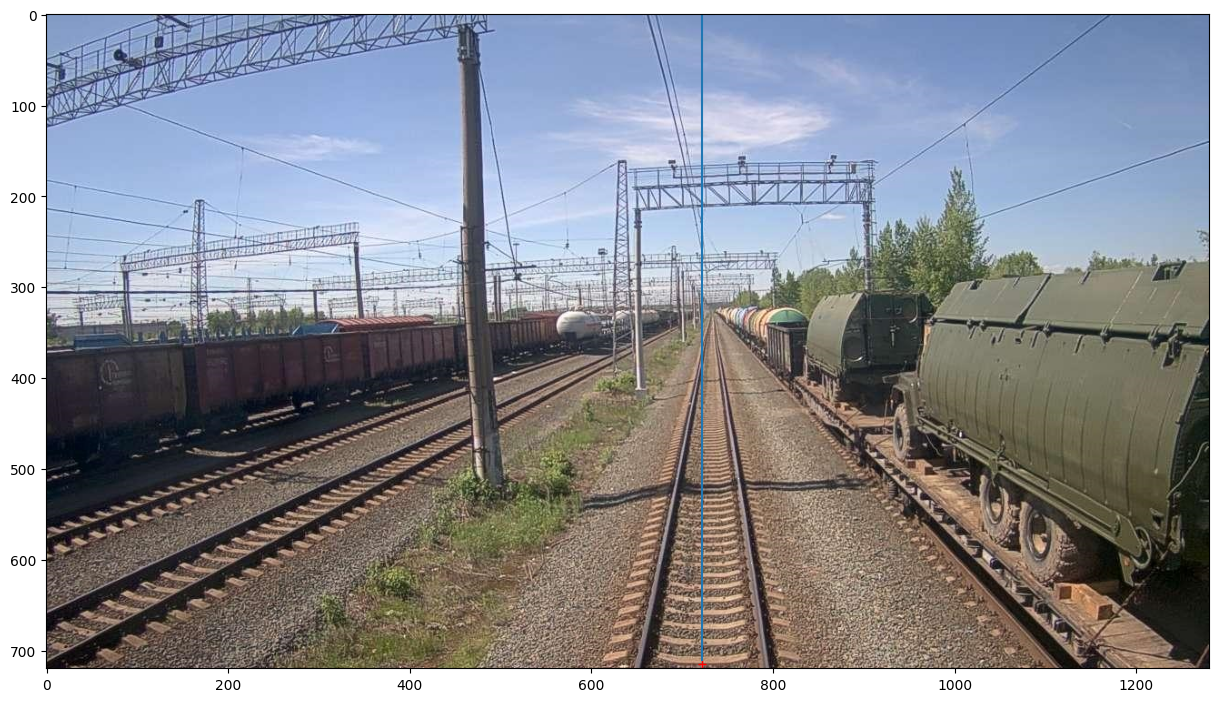

In [4]:
#  центр колеи
plt.figure(figsize=(15, 10))
plt.imshow(img)
x_c = 722
plt.plot([x_c], [715], marker='+', color='red', linewidth=0)
plt.plot([x_c, x_c], [0, 710])


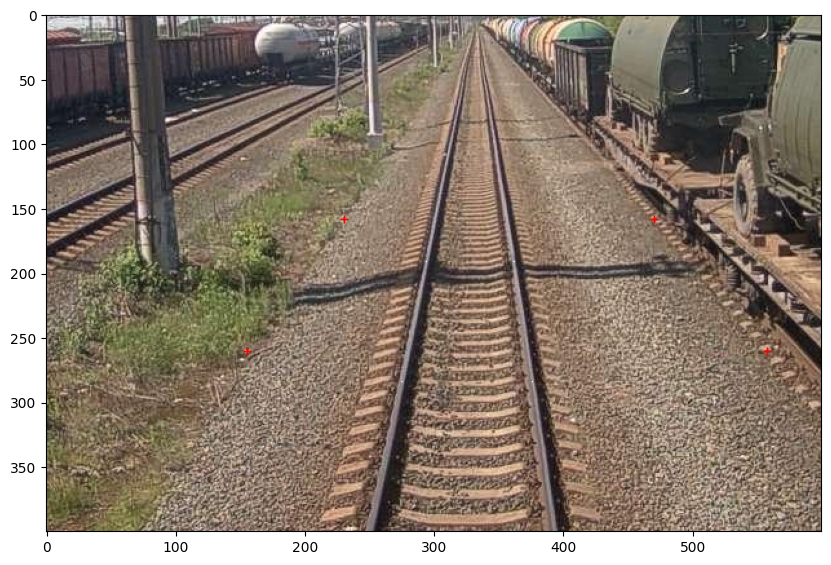

In [7]:
img = Image.open(r'./image.jpg')
img = np.array(img)[320:,400:1000,:]
w, h = img.shape[1], img.shape[0]



# fig, (asrc, anorm, afull) = plt.subplots(1, 3)
fig, (asrc) = plt.subplots(1, 1, figsize=(10, 8))
# asrc.set_title('Исходное изображение')
# anorm.set_title('Выбранная трапеция')
# afull.set_title('Все изображение с учетом перспективы')

# asrc.imshow(img)

# Координаты углов трапеции по картинке (тут получены вручную)
top_left = [230, 158]
top_right = [470, 158]
bottom_left = [155, 260]
bottom_right = [558, 260]

img_points = np.float32([top_left, top_right, bottom_left, bottom_right])

# Показать кординаты углов на картинке
asrc.imshow(img)
asrc.plot(*img_points.T, marker='+', color='red', linewidth=0)


(250, 200, 3)
w = 6892mm, h = 10200, ratio = 1: 1.48
один пиксель ~46мм


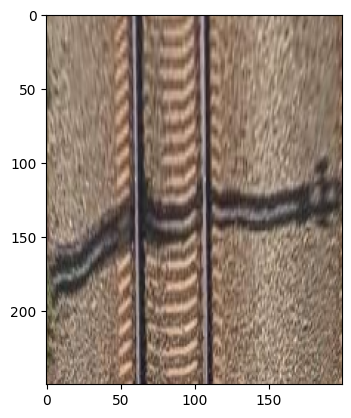

In [8]:
# wmm = 150
# hmm = 222
wmm = 200
hmm = 250
real_pointst = np.float32([[0, 0], [wmm, 0], [0, hmm], [wmm, hmm]])

# Вычисление матрицы коррекции перспективы
pmatrix = cv.getPerspectiveTransform(img_points, real_pointst)

# выпрямленная картинка в пределах угла трапеции
cropped = cv.warpPerspective(img, pmatrix, (wmm, hmm))

# Показать выпрямленную картинку
# plt.axis('equal')
plt.imshow(cropped)

print(cropped.shape)
print('w = 6892mm, h = 10200, ratio = 1: 1.48')
print('один пиксель ~46мм')

x_min, x_max, y_min, y_max -4064.3643 5543.171 381.40195 12494.898


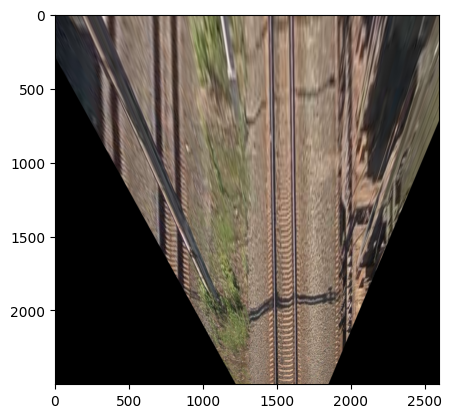

In [9]:
# Пересчет всей картинки (не только в пределах координат трапеции)

# Углы исходной каринки
corners = np.float32([[0, 0], [w, 0], [0, h], [w, h]]).reshape(-1, 1, 2)
# Положение этих точек в реальном пространстве (применяем к ним матрицу коррекции перспективы)
t_corners = cv.perspectiveTransform(corners, pmatrix)
# Границы изображения в реальном пространстве
x_min, y_min = t_corners.min(axis=0).ravel()
x_max, y_max = t_corners.max(axis=0).ravel()
print('x_min, x_max, y_min, y_max', x_min, x_max, y_min, y_max)
# Размеры области
new_w = int(np.ceil(x_max - x_min))
new_h = int(np.ceil(y_max - y_min))

# Матрица переноса (сдвиг картинки в положительную область
pmatrix_shift = np.array([[3, 0, 1300],
                          [0, 2.5, 1600],
                          [0, 0, 1]])
# Произведение матрицы переноса и матрицы перспективы
pmatrix_new = pmatrix_shift @ pmatrix

# полная картинка
corr = cv.warpPerspective(np.array(img), pmatrix_new, (2600, 2500))

plt.imshow(corr)
# print(corr.shape)

# plt.savefig('res.png')
# plt.show()

(400, 600, 3)


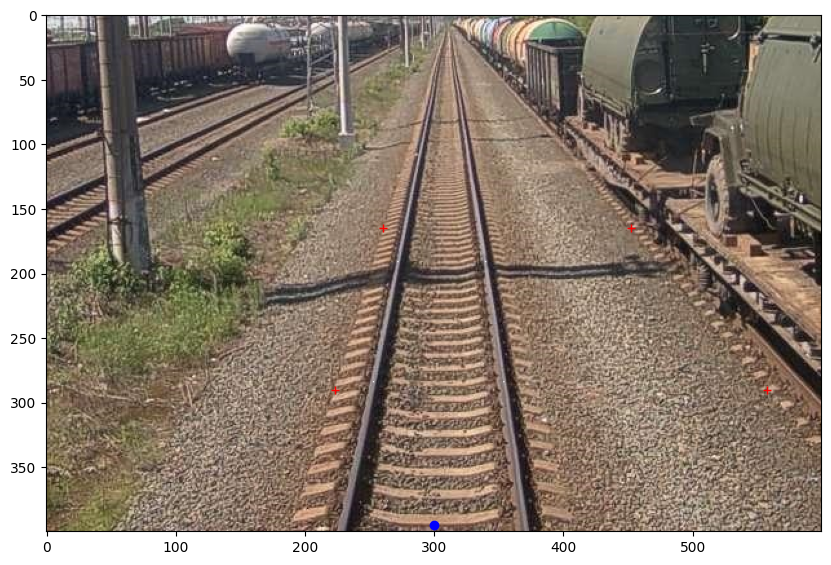

In [21]:
# dr var

img = Image.open(r'./image.jpg')

# обрезал по центра колеи
img = np.array(img)[320:,x_c-300:x_c+300,:]
w, h = img.shape[1], img.shape[0]




fig, ax = plt.subplots(1, 1, figsize=(10, 8))



# Координаты углов трапеции по картинке (тут получены вручную)
top_left = [260, 165]
top_right = [452, 165]
bottom_left = [223, 290]
bottom_right = [558, 290]

img_points = np.float32([top_left, top_right, bottom_left, bottom_right])

# Показать кординаты углов на картинке
print(img.shape)
ax.imshow(img)
ax.plot(*img_points.T, marker='+', color='red', linewidth=0)
ax.plot([(img.shape[1] / 2)], [img.shape[0]-5], marker='o', color='blue', linewidth=0)

In [14]:
img = Image.fromarray(img)
img.save('cut.jpg')

(250, 200, 3)
w = 6892mm, h = 10200, ratio = 1: 1.48
один пиксель ~46мм


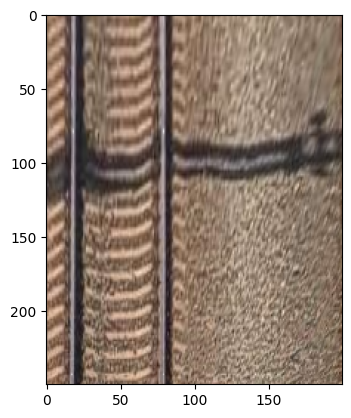

In [22]:
# wmm = 150
# hmm = 222
wmm = 200
hmm = 250
real_pointst = np.float32([[0, 0], [wmm, 0], [0, hmm], [wmm, hmm]])

# Вычисление матрицы коррекции перспективы
pmatrix = cv.getPerspectiveTransform(img_points, real_pointst)

# выпрямленная картинка в пределах угла трапеции
cropped = cv.warpPerspective(img, pmatrix, (wmm, hmm))

# Показать выпрямленную картинку
# plt.axis('equal')
plt.imshow(cropped)

print(cropped.shape)
print('w = 6892mm, h = 10200, ratio = 1: 1.48')
print('один пиксель ~46мм')